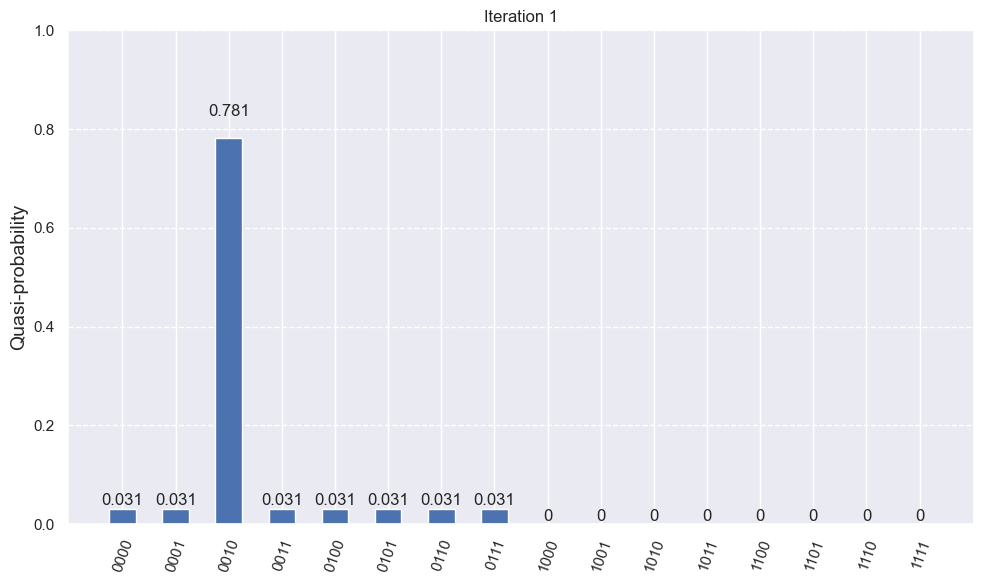

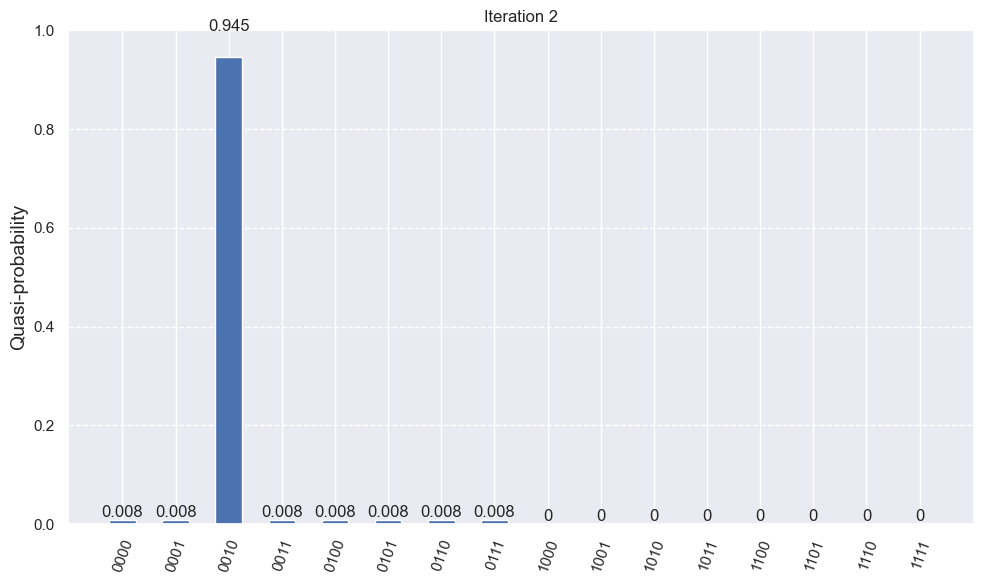

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import C3XGate
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_distribution

sns.set()

# Logic functions
def apply_oracle(qc):
    qc.x([0, 2, 3]); qc.h(3)
    qc.append(C3XGate(), [0, 1, 2, 3])
    qc.h(3); qc.x([0, 2, 3]); qc.barrier()

def apply_diffuser(qc):
    qc.h([0, 1, 2]); qc.x([0, 1, 2]); qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2); qc.x([0, 1, 2]); qc.h([0, 1, 2]); qc.barrier()

# Execution 
qc = QuantumCircuit(4)
qc.h([0, 1, 2])

# Iteration 1
apply_oracle(qc)
apply_diffuser(qc)
state1 = Statevector.from_instruction(qc).probabilities_dict()

# Iteration 2
apply_oracle(qc)
apply_diffuser(qc)
state2 = Statevector.from_instruction(qc).probabilities_dict()

# Create the figures with a specific size to prevent crowded labels
fig1, ax1 = plt.subplots(figsize=(10, 6))

# Plot 1
plot_distribution(state1, ax=ax1, title="Iteration 1")
ax1.set_ylim(0, 1)  # Fix the scale
plt.tight_layout()   # Fix overlapping text
fig1.savefig('first_iter.png')

# Plot 2
fig2, ax2 = plt.subplots(figsize=(10, 6))
plot_distribution(state2, ax=ax2, title="Iteration 2")
ax2.set_ylim(0, 1)  # Fix the scale
plt.tight_layout()   # Fix overlapping text
fig2.savefig('second_iter.png')

plt.show()